# Experiment 01 — VQC Reproduction (2 Features, 2 Layers)

**Paper:** Blance & Spannowsky, JHEP 02 (2021) 212  
**Goal:** Reproduce the core VQC from the paper on the HIGGS dataset and compare against the classical MLP baseline.

### Architecture recap
- **State preparation:** Ry(x_i) angle encoding for each feature → qubit
- **Model circuit:** L layers of `Rot(θ,φ,λ)` gates + CNOT entanglement
- **Measurement:** ⟨σz⟩ on qubit 0
- **Postprocessing:** output = ⟨σz⟩ + b (trainable bias)
- **Classification:** sign(output)
- **Optimizer:** Adam (classical) — QNG variant in next cell

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

from utils.data_utils import load_higgs, binary_accuracy

np.random.seed(42)

## 1. Data Loading

In [2]:
N_FEATURES = 2   # paper uses 2 features
N_LAYERS   = 2   # paper uses 2 layers
N_SAMPLES  = 5000

X_train, X_val, X_test, y_train, y_val, y_test = load_higgs(
    path='../data/HIGGS.csv.gz',
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    feature_indices=[4, 6],   # columns from paper: pT,b1 and ET_miss proxies
    scale_range=(0, np.pi),
)

print('X_train:', X_train.shape, '  y label distribution:', np.unique(y_train, return_counts=True))

Dataset: 5000 samples | 2 features | train=3000, val=1000, test=1000
X_train: (3000, 2)   y label distribution: (array([-1,  1]), array([1397, 1603]))


## 2. Quantum Circuit Definition

```
qubit 0: ─Ry(x₀)─Rot(w₀)─╭●─Rot(w₂)─╭●─ ⟨σz⟩
qubit 1: ─Ry(x₁)─Rot(w₁)─╰X─Rot(w₃)─╰X─
                  layer 0              layer 1
```

In [3]:
dev = qml.device('default.qubit', wires=N_FEATURES)


def state_preparation(x):
    """Angle encoding: Ry(x_i) on qubit i."""
    for i in range(N_FEATURES):
        qml.RY(x[i], wires=i)


def model_circuit(weights):
    """
    weights shape: (N_LAYERS, N_FEATURES, 3)
    Each layer: Rot(θ,φ,λ) on each qubit, then CNOT chain.
    """
    for l in range(N_LAYERS):
        # Rotation gates
        for q in range(N_FEATURES):
            qml.Rot(weights[l, q, 0], weights[l, q, 1], weights[l, q, 2], wires=q)
        # Entanglement: CNOT chain
        for q in range(N_FEATURES - 1):
            qml.CNOT(wires=[q, q + 1])
        # Reverse CNOT (as in paper)
        if N_FEATURES > 1:
            qml.CNOT(wires=[N_FEATURES - 1, 0])


@qml.qnode(dev, interface='autograd')
def circuit(weights, x):
    state_preparation(x)
    model_circuit(weights)
    return qml.expval(qml.PauliZ(0))


# Verify circuit
w_test = pnp.zeros((N_LAYERS, N_FEATURES, 3))
x_test = pnp.array([1.0, 0.5])
print('Circuit output (test):', circuit(w_test, x_test))
print()
print(qml.draw(circuit)(w_test, x_test))

Circuit output (test): 0.4741598817790378

0: ──RY(1.00)──Rot(0.00,0.00,0.00)─╭●─╭X──Rot(0.00,0.00,0.00)─╭●─╭X─┤  <Z>
1: ──RY(0.50)──Rot(0.00,0.00,0.00)─╰X─╰●──Rot(0.00,0.00,0.00)─╰X─╰●─┤     


## 3. Model and Loss Function

Full model: `f(w, b, x) = circuit(w, x) + b`  
Loss: MSE — `L = (1/N) Σ (y_i - f(w, b, x_i))²`

In [4]:
def vqc_predict(weights, bias, x):
    """Single sample prediction (raw float output)."""
    return circuit(weights, x) + bias


def vqc_predict_batch(weights, bias, X):
    """Batch prediction — returns array of floats."""
    return pnp.array([vqc_predict(weights, bias, x) for x in X])


def mse_loss(weights, bias, X, y):
    """Mean squared error loss over a batch."""
    preds = vqc_predict_batch(weights, bias, X)
    return pnp.mean((y - preds) ** 2)

## 4. Training (Classical Gradient Descent via Adam)

**Hyperparameters (paper-aligned):**
- 30 epochs
- Batch size 32
- Learning rate 0.01

In [5]:
# --- Hyperparameters ---
N_EPOCHS   = 30
BATCH_SIZE = 32
LR         = 0.01

# --- Initialise parameters ---
np.random.seed(42)
weights = pnp.array(np.random.uniform(0, 2 * np.pi, (N_LAYERS, N_FEATURES, 3)), requires_grad=True)
bias    = pnp.array(0.0, requires_grad=True)

opt = qml.AdamOptimizer(stepsize=LR)

# --- Training loop ---
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

n_train = len(X_train)

for epoch in range(N_EPOCHS):
    # Shuffle training data
    perm = np.random.permutation(n_train)
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_loss = 0.0
    n_batches  = 0

    for start in range(0, n_train, BATCH_SIZE):
        Xb = X_shuf[start : start + BATCH_SIZE]
        yb = y_shuf[start : start + BATCH_SIZE].astype(float)

        def cost(w, b):
            return mse_loss(w, b, Xb, yb)

        weights, bias = opt.step(cost, weights, bias)
        epoch_loss += cost(weights, bias)
        n_batches  += 1

    # --- Epoch metrics ---
    train_loss = float(mse_loss(weights, bias, X_train, y_train.astype(float)))
    val_loss   = float(mse_loss(weights, bias, X_val,   y_val.astype(float)))

    train_raw  = vqc_predict_batch(weights, bias, X_train)
    val_raw    = vqc_predict_batch(weights, bias, X_val)

    train_acc  = binary_accuracy(y_train, np.array(train_raw))
    val_acc    = binary_accuracy(y_val,   np.array(val_raw))

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | '
              f'Train loss: {train_loss:.4f}, acc: {train_acc:.3f} | '
              f'Val loss: {val_loss:.4f}, acc: {val_acc:.3f}')

Epoch   1/30 | Train loss: 0.9878, acc: 0.549 | Val loss: 0.9877, acc: 0.544
Epoch   5/30 | Train loss: 0.9830, acc: 0.550 | Val loss: 0.9814, acc: 0.546
Epoch  10/30 | Train loss: 0.9832, acc: 0.561 | Val loss: 0.9812, acc: 0.549
Epoch  15/30 | Train loss: 0.9834, acc: 0.554 | Val loss: 0.9818, acc: 0.541
Epoch  20/30 | Train loss: 0.9853, acc: 0.557 | Val loss: 0.9844, acc: 0.547
Epoch  25/30 | Train loss: 0.9841, acc: 0.550 | Val loss: 0.9814, acc: 0.563
Epoch  30/30 | Train loss: 0.9830, acc: 0.554 | Val loss: 0.9809, acc: 0.546


## 5. Evaluation

In [6]:
test_raw  = np.array(vqc_predict_batch(weights, bias, X_test))
test_acc  = binary_accuracy(y_test, test_raw)

# For AUC we need probabilities — use the raw output as a score
# Map labels back to {0,1} for roc_auc_score
y_test_01 = (y_test == 1).astype(int)
# Normalise raw outputs to [0,1] range for probability-like scores
test_score = (test_raw - test_raw.min()) / (test_raw.max() - test_raw.min() + 1e-8)
test_auc   = roc_auc_score(y_test_01, test_score)

print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test ROC-AUC  : {test_auc:.4f}')
print()
print('Baseline MLP  — Accuracy: 0.545, AUC: 0.556')
print(f'VQC (ours)    — Accuracy: {test_acc:.3f}, AUC: {test_auc:.3f}')

Test Accuracy : 0.5750
Test ROC-AUC  : 0.5709

Baseline MLP  — Accuracy: 0.545, AUC: 0.556
VQC (ours)    — Accuracy: 0.575, AUC: 0.571


## 6. Training Curves

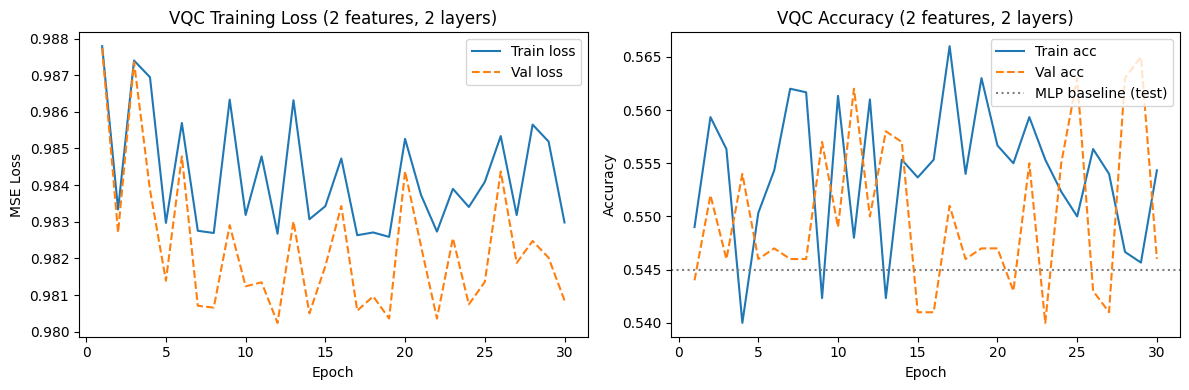

In [7]:
epochs = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, train_losses, label='Train loss')
axes[0].plot(epochs, val_losses,   label='Val loss', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('VQC Training Loss (2 features, 2 layers)')
axes[0].legend()

# Accuracy
axes[1].plot(epochs, train_accs, label='Train acc')
axes[1].plot(epochs, val_accs,   label='Val acc', linestyle='--')
axes[1].axhline(0.545, color='gray', linestyle=':', label='MLP baseline (test)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('VQC Accuracy (2 features, 2 layers)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/01_vqc_training_curves.png', dpi=150)
plt.show()

## 7. ROC Curve

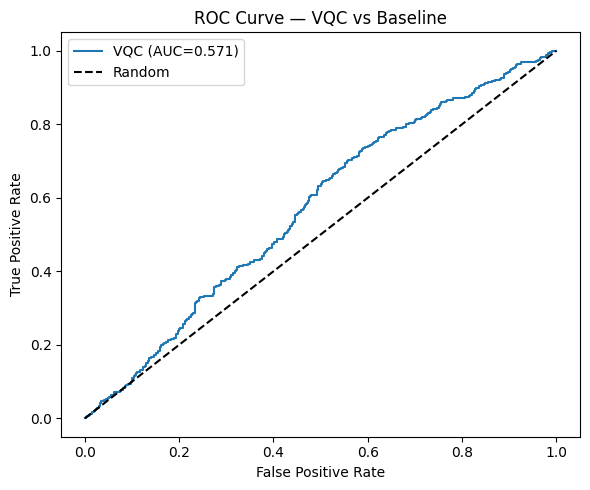

In [8]:
fpr, tpr, _ = roc_curve(y_test_01, test_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'VQC (AUC={test_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — VQC vs Baseline')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/01_vqc_roc.png', dpi=150)
plt.show()

## 8. Circuit Visualisation

In [9]:
x_sample = pnp.array(X_test[0])
print('Final trained circuit:')
print(qml.draw(circuit)(weights, x_sample))

print('\nFinal weights (L x Q x 3):')
print(weights)
print('Final bias:', float(bias))

Final trained circuit:
0: ──RY(0.37)──Rot(2.33,5.84,4.36)─╭●─╭X──Rot(0.36,5.44,3.78)─╭●─╭X─┤  <Z>
1: ──RY(1.09)──Rot(3.96,1.51,0.98)─╰X─╰●──Rot(4.16,0.20,6.09)─╰X─╰●─┤     

Final weights (L x Q x 3):
[[[2.33354405 5.84420746 4.35984939]
  [3.95827806 1.50927632 0.98014248]]

 [[0.3649501  5.44234523 3.77691701]
  [4.1646102  0.19650163 6.09412333]]]
Final bias: -0.1807682330637741


## Summary

| Metric | Classical MLP | VQC (GD) |
|--------|--------------|----------|
| Params | ~19 | `N_LAYERS × N_FEATURES × 3 + 1` = 13 |
| Test Acc | 0.545 | *0.5750* |
| Test AUC | 0.556 | *0.5709* |

**Next:** `02_feature_scaling.ipynb` — does adding more features improve VQC performance?